In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt 
import seaborn as sns

import joblib 
import os

from sklearn.preprocessing import  StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')

# Step1.  load dataset

In [2]:
df = pd.read_csv("../data/online_retail.csv", encoding="ISO-8859-1")

df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2023-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2023-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2023-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2023-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2023-12-09 12:50:00,4.95,12680.0,France


In [4]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (541909, 8)

Columns:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtyp

In [5]:
df.columns


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [6]:
df.shape

(541909, 8)

In [7]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


# step 2. Data Cleaning

In [8]:
df.isnull().sum()     # finding null vslues

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
df= df.dropna(subset=['CustomerID'])   #remove missing customerID 
print(df.shape)

(406829, 8)


In [10]:
df =df.drop_duplicates()  # removing duplicate rows
print(df.shape)

(401604, 8)


In [11]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]      # removing cancelled order like which are starting from "C38736"
df.shape 

(392732, 8)

In [12]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])       #Converting date column
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392732 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392732 non-null  object        
 1   StockCode    392732 non-null  object        
 2   Description  392732 non-null  object        
 3   Quantity     392732 non-null  int64         
 4   InvoiceDate  392732 non-null  datetime64[ns]
 5   UnitPrice    392732 non-null  float64       
 6   CustomerID   392732 non-null  float64       
 7   Country      392732 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.0+ MB


# Create TotalAmount Feature
- this will help later RFM analysis

In [13]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [14]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


# Final Dataset Check

In [15]:
print("Final Shape :", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicates:")
print(df.duplicated().sum())

Final Shape : (392732, 9)

Missing Values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
dtype: int64

Duplicates:
0


# Save Cleaned Dataset

In [16]:
df.to_csv("../data/cleaned_online_retail.csv", index=False)

In [17]:
df.shape


(392732, 9)

In [18]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


# Step 3. Exploratory Data Analysis (EDA)

In [19]:
plt.style.use('ggplot')

### 1. Transaction Volume by Country :

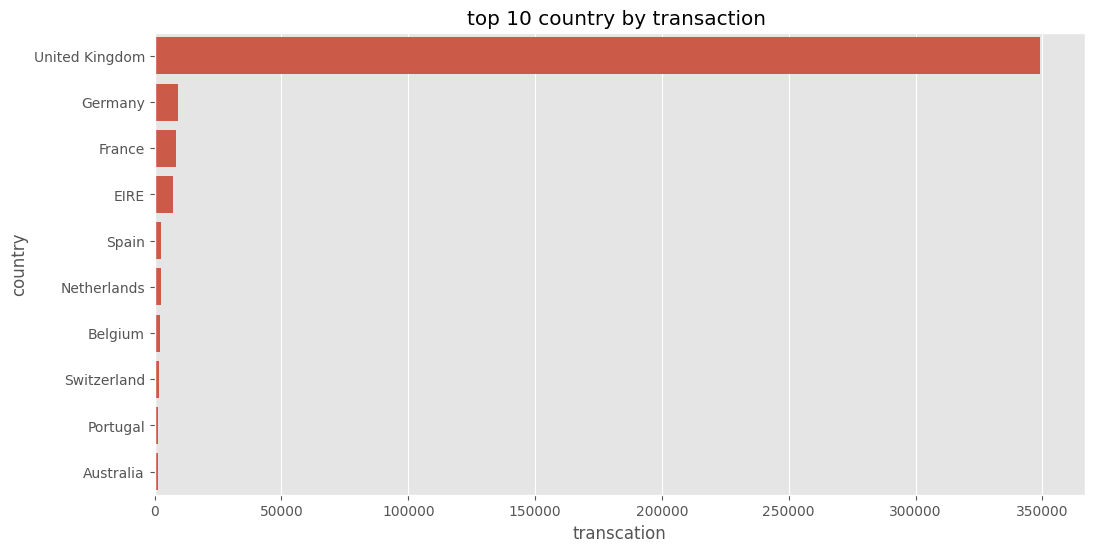

In [20]:
top_countries= df['Country'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x= top_countries.values,
            y= top_countries.index)

plt.title("top 10 country by transaction ")
plt.xlabel("transcation")
plt.ylabel("country")
plt.show()

## 2. Top 10 Selling Products

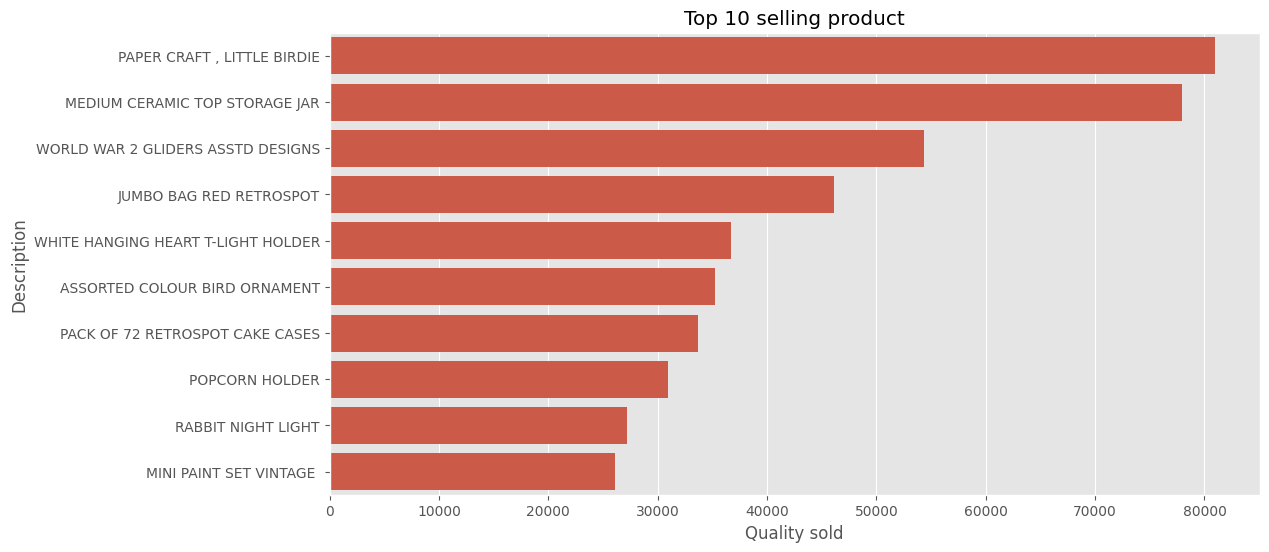

In [21]:
top_products=(
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 selling product")
plt.xlabel("Quality sold")
plt.show()

## 3. Monthly Revenue Trend

In [22]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')   #create month column

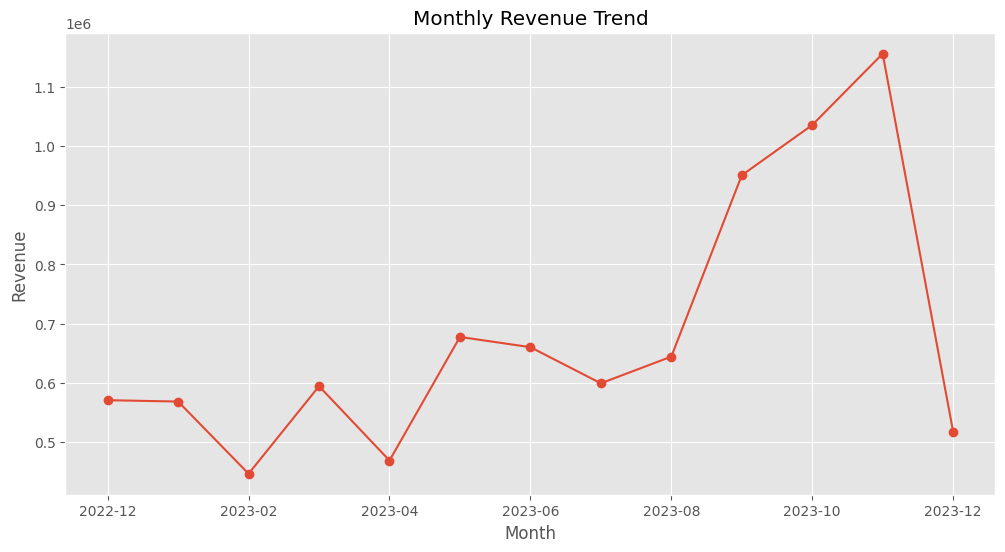

In [23]:
monthly_sales =(
    df.groupby('Month')['TotalAmount']
    .sum()
)

monthly_sales.index=monthly_sales.index.astype(str)

plt.figure(figsize=(12,6))
monthly_sales.plot(marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

# 4. Customer Spending Distribution

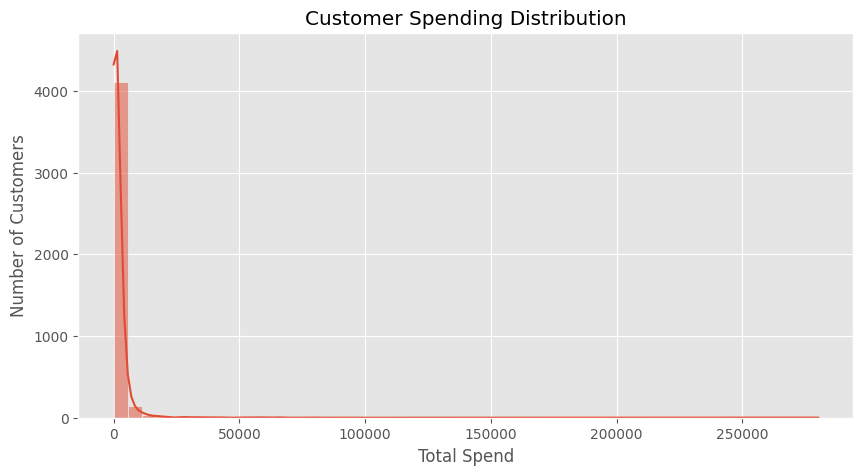

In [24]:
customer_spend = df.groupby("CustomerID")["TotalAmount"].sum()

plt.figure(figsize=(10,5))
sns.histplot(customer_spend, bins=50, kde=True)
plt.title("Customer Spending Distribution")
plt.xlabel("Total Spend")
plt.ylabel("Number of Customers")
plt.show()

# RFM Analysis

### Create RFM Table 

In [25]:
latest_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (latest_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


### RFM Distribution

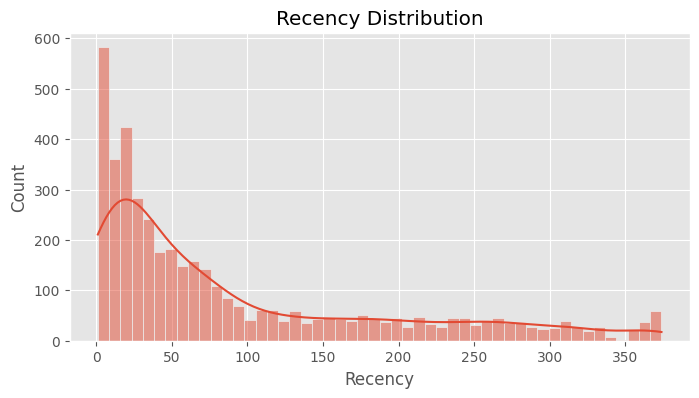

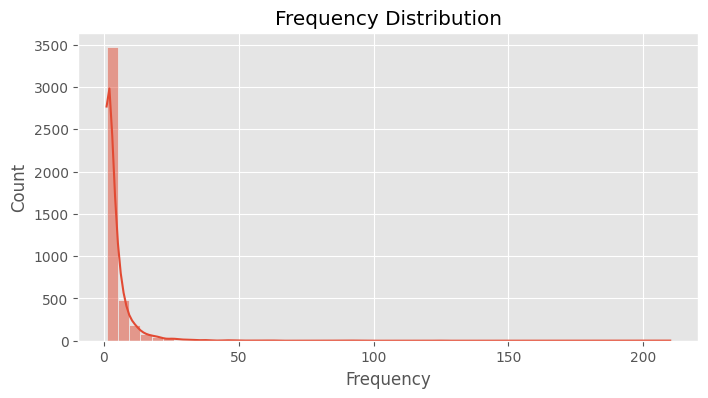

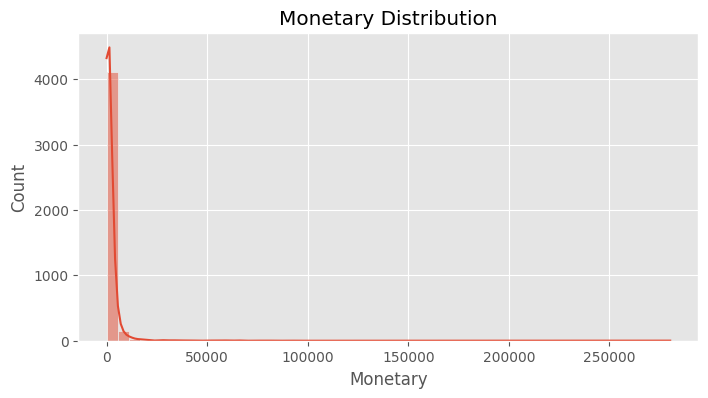

In [26]:
plt.figure(figsize=(8,4))
sns.histplot(rfm["Recency"], bins=50, kde=True)
plt.title("Recency Distribution")
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(rfm["Frequency"], bins=50, kde=True)
plt.title("Frequency Distribution")
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(rfm["Monetary"], bins=50, kde=True)
plt.title("Monetary Distribution")
plt.show()

# Scale RFM Data

In [27]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm[["Recency", "Frequency", "Monetary"]])

rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"],
    index=rfm.index
)

rfm_scaled_df.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334858,-0.424675,8.363977
12347.0,-0.905199,0.354080,0.251779
12348.0,-0.175186,-0.035297,-0.027938
12349.0,-0.735196,-0.424675,-0.032357
12350.0,2.174855,-0.424675,-0.190780


# Elbow Method

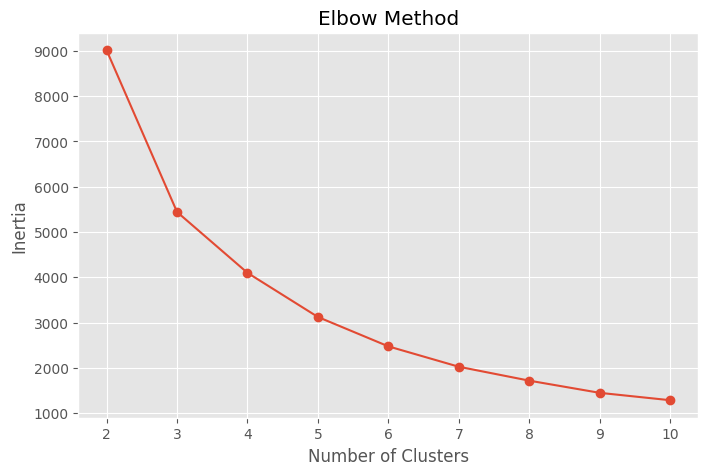

In [28]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled_df)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2, 11), inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

# Silhouette Score

In [29]:
silhouette_scores = {}

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled_df)
    score = silhouette_score(rfm_scaled_df, labels)
    silhouette_scores[k] = score
    print(f"K = {k}, Silhouette Score = {score}")

K = 2, Silhouette Score = 0.8958611714763172
K = 3, Silhouette Score = 0.594372718368177
K = 4, Silhouette Score = 0.6161304312712135
K = 5, Silhouette Score = 0.6157533823191146
K = 6, Silhouette Score = 0.5983135755401275
K = 7, Silhouette Score = 0.5162261304353631
K = 8, Silhouette Score = 0.4768394910742316
K = 9, Silhouette Score = 0.4777309979034703
K = 10, Silhouette Score = 0.47789392178465984


# Train KMeans Model

In [30]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled_df)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,0
12347.0,2,7,4310.00,3
12348.0,75,4,1797.24,3
12349.0,19,1,1757.55,3
12350.0,310,1,334.40,1


# Cluster Interpretation

In [31]:
cluster_summary = rfm.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
}).round(2)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,15.67,22.05,12435.09
1,248.56,1.55,476.33
2,7.38,82.69,127187.96
3,43.91,3.66,1344.28


# Add Segment Labels

In [32]:
def assign_segment(row):
    if row["Recency"] <= rfm["Recency"].median() and row["Frequency"] >= rfm["Frequency"].median() and row["Monetary"] >= rfm["Monetary"].median():
        return "High-Value"
    elif row["Frequency"] >= rfm["Frequency"].median() and row["Monetary"] >= rfm["Monetary"].median():
        return "Regular"
    elif row["Recency"] > rfm["Recency"].median() and row["Frequency"] < rfm["Frequency"].median():
        return "At-Risk"
    else:
        return "Occasional"

rfm["Segment"] = rfm.apply(assign_segment, axis=1)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,0,At-Risk
12347.0,2,7,4310.00,3,High-Value
12348.0,75,4,1797.24,3,Regular
12349.0,19,1,1757.55,3,Occasional
12350.0,310,1,334.40,1,At-Risk


# Cluster Plot

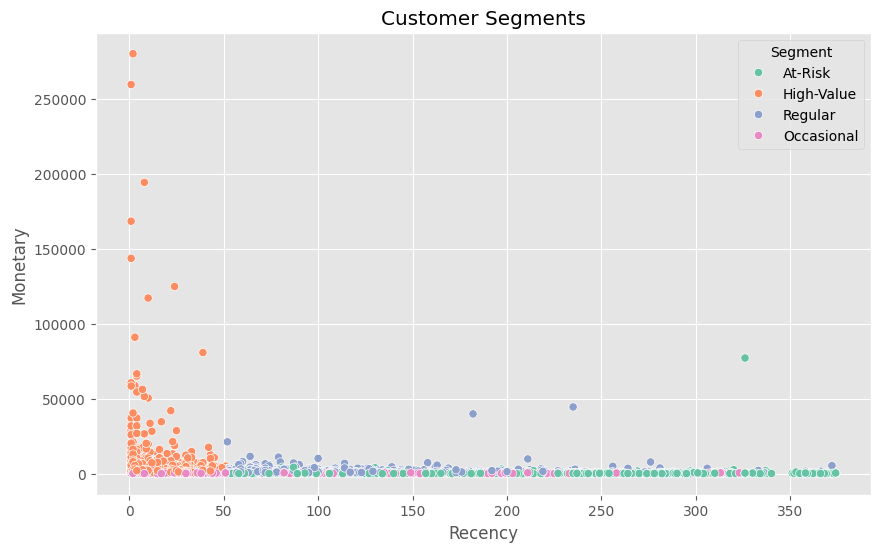

In [33]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Segment",
    palette="Set2"
)
plt.title("Customer Segments")
plt.show()

# Product Recommendation System

### Create Customer Product Matrix

In [34]:
product_matrix = df.pivot_table(
    index="CustomerID",
    columns="Description",
    values="Quantity",
    aggfunc="sum",
    fill_value=0
)

product_matrix.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12347.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12349.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12350.0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Convert Quantity to Purchase/Not Purchase

In [35]:
product_matrix = product_matrix.applymap(lambda x: 1 if x > 0 else 0)

### Product Similarity

In [36]:
product_similarity = cosine_similarity(product_matrix.T)

product_similarity_df = pd.DataFrame(
    product_similarity,
    index=product_matrix.columns,
    columns=product_matrix.columns
)

product_similarity_df.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
Description,,,,,,,,,,,,,,,,,,,,,
4 PURPLE FLOCK DINNER CANDLES,1.000000,0.000000,0.017961,0.023583,0.000000,0.000000,0.028050,0.000000,0.031384,0.017125,...,0.0,0.042333,0.043885,0.032001,0.0,0.026774,0.0,0.061379,0.000000,0.042333
50'S CHRISTMAS GIFT BAG LARGE,0.000000,1.000000,0.058277,0.038261,0.000000,0.036073,0.060676,0.332508,0.033945,0.083348,...,0.0,0.045787,0.047465,0.034612,0.0,0.094114,0.0,0.033193,0.000000,0.022893
DOLLY GIRL BEAKER,0.017961,0.058277,1.000000,0.144437,0.100000,0.037139,0.046852,0.066259,0.061159,0.200227,...,0.0,0.023570,0.048868,0.089087,0.0,0.096896,0.0,0.034174,0.028868,0.070711
I LOVE LONDON MINI BACKPACK,0.023583,0.038261,0.144437,1.000000,0.131306,0.048766,0.041013,0.043501,0.126195,0.112676,...,0.0,0.061898,0.048125,0.035093,0.0,0.039148,0.0,0.056091,0.000000,0.061898
I LOVE LONDON MINI RUCKSACK,0.000000,0.000000,0.100000,0.131306,1.000000,0.000000,0.000000,0.000000,0.000000,0.095346,...,0.0,0.000000,0.000000,0.089087,0.0,0.074536,0.0,0.085436,0.000000,0.000000


# Recommendation Function

In [37]:
def recommend_products(product_name, top_n=5):
    product_name = product_name.upper()

    matching_products = [
        product for product in product_similarity_df.index
        if product_name in product.upper()
    ]

    if len(matching_products) == 0:
        return "Product not found."

    selected_product = matching_products[0]

    recommendations = product_similarity_df[selected_product].sort_values(ascending=False)[1:top_n+1]

    return recommendations.index.tolist()

### Test:

In [38]:
recommend_products("WHITE HANGING HEART")

['RED HANGING HEART T-LIGHT HOLDER',
 'CANDLEHOLDER PINK HANGING HEART',
 'HEART OF WICKER LARGE',
 'HEART OF WICKER SMALL',
 'WOODEN PICTURE FRAME WHITE FINISH']

# Save Models

In [39]:
os.makedirs("../models", exist_ok=True)

joblib.dump(kmeans, "../models/kmeans_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(product_similarity_df, "../models/product_similarity.pkl")
joblib.dump(rfm, "../models/rfm_data.pkl")

print("Models saved successfully.")

Models saved successfully.
